In [130]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score

sys.path.append(str(Path().resolve().parent))

from src.data import get_data
from src.features import generate_features
from src.backtest import backtest, results_table, optimize, optimize_assets, fit_strategy
from src.strategy import (
    logistic_strategy, 
    momentum_strategy, 
    momentum_volatility_strategy, 
    mean_reversion_strategy, 
    momentum_trend_strategy, 
    momentum_voluratio_strategy,
    randforest_strategy
)
from src.visualization import plot_performance
from src.ml import build_ml_dataset, train_logistic, train_randforest
from src.finance import calculate_beta

## Strategy Leaderboard 

In [131]:
df = pd.read_csv("../outputs/experiment_results.csv")
df['Generalization Ratio'] = (df['Test Sharpe'] - df['Train Sharpe']) / df['Train Sharpe']

In [132]:
summary = (
    df.groupby("Strategy")
      .agg({
          "Train Sharpe":"mean",
          "Test Sharpe":"mean",
          "Generalization Ratio":"mean",
          "Train Volatility":"mean",
          "Test Volatility":"mean",
          "Train Max DD":"mean",
          "Test Max DD":"mean"
      })
      .sort_values(
          "Test Sharpe",
          ascending=False
      )
)

summary

,Train Sharpe,Test Sharpe,Generalization Ratio,Train Volatility,Test Volatility,Train Max DD,Test Max DD
Strategy,,,,,,,
Momentum,0.710472,0.969023,0.794371,0.259419,0.268050,-0.323893,-0.248375
Momentum + Rolling Volatility,0.820345,0.932915,0.438721,0.231243,0.262417,-0.252748,-0.236441
Logistic Regression,0.633086,0.900300,1.145068,0.291169,0.191574,-0.400370,-0.206873
Random Forest,8.645609,0.827776,-0.906754,0.248711,0.225066,0.000000,-0.246249
Momentum + Trend Strength,0.519231,0.677825,-0.907412,0.207372,0.227665,-0.298870,-0.230230
Momentum + Volume Ratio,0.466498,0.498473,0.445975,0.181039,0.191037,-0.263294,-0.223063
Mean Reversion,0.809215,-0.037417,-1.100116,0.139963,0.070043,-0.121226,-0.081959


In [133]:
summary = (
    df.groupby("Strategy")
      .agg({
          "Generalization Ratio":"mean"
      })
      .sort_values(
        "Generalization Ratio",
        ascending=False
      )
)

summary

,Generalization Ratio
Strategy,
Logistic Regression,1.145068
Momentum,0.794371
Momentum + Volume Ratio,0.445975
Momentum + Rolling Volatility,0.438721
Random Forest,-0.906754
Momentum + Trend Strength,-0.907412
Mean Reversion,-1.100116


In [134]:
summary = (
    df.groupby("Asset")
      .agg({
          "Train Sharpe":"mean",
          "Test Sharpe":"mean",
          "Generalization Ratio":"mean",
          "Train Volatility":"mean",
          "Test Volatility":"mean",
          "Train Max DD":"mean",
          "Test Max DD":"mean"
      })
      .sort_values(
          "Generalization Ratio",
          ascending=False
      )
)

summary

,Train Sharpe,Test Sharpe,Generalization Ratio,Train Volatility,Test Volatility,Train Max DD,Test Max DD
Asset,,,,,,,
META,2.354365,1.182972,2.318213,0.230187,0.235751,-0.262483,-0.238177
ECL,1.970069,0.876421,1.220901,0.169720,0.130297,-0.281511,-0.129783
GLD,2.591326,1.433605,0.914328,0.090616,0.105376,-0.112342,-0.090127
BE,2.216315,0.665593,0.537741,0.484710,0.496505,-0.319870,-0.347950
JNJ,2.247526,0.544844,0.333804,0.119395,0.110730,-0.159388,-0.136071
SPY,2.483441,1.145525,0.245923,0.112727,0.084198,-0.136018,-0.089253
DOCS,1.848214,0.324593,0.128115,0.347312,0.338411,-0.247951,-0.244405
NVDA,2.938218,1.456602,0.090854,0.332709,0.298585,-0.314419,-0.242697
JPM,2.417849,0.899118,0.056153,0.172001,0.111980,-0.162366,-0.140205


## Market Regime Analysis

In [135]:
base_df = get_data("SPY", "2011-01-01", "2026-01-01")
base_df = generate_features(base_df)

train = base_df.loc["2011":"2015"].copy()
future = base_df.loc["2016":"2026"].copy()

[*********************100%***********************]  1 of 1 completed


In [136]:
windows = range(1, 51)
strategies = [
    ('Momentum', momentum_strategy, 'mom', None, None),
    ('Mean Reversion', mean_reversion_strategy, 'mr', range(2, 100, 2), None),
    ("Momentum + Trend Strength", momentum_trend_strategy, "mo_tr", None, None),
    ("Momentum + Rolling Volatility", momentum_volatility_strategy, "mo_vo", range(2, 100, 2), None),
    ("Momentum + Volume Ratio", momentum_voluratio_strategy, "mo_vr", None, None),
    ("Logistic Regression", logistic_strategy, "lr", None, train_logistic),
    ("Random Forest", randforest_strategy, "rf", None, train_randforest)
]

In [137]:
future_results = future.copy()

for strategy in strategies:

    print(strategy[0])

    _, future_temp, _, _, _, _ = fit_strategy(
        train,
        future,
        strategy,
        windows,
        feature_set="v1",
        windowplot=False
    )

    ending = strategy[2]

    for col in (
        f"signal_{ending}",
        f"strategy_returns_{ending}",
        f"cumulative_returns_{ending}"
    ):

        if col in future_temp.columns:
            future_results[col] = future_temp[col]

Momentum
Market Sharpe Ratio: 0.6929
Best Momentum Strategy window: 3
Best Sharpe ratio: 0.6638

Mean Reversion
Market Sharpe Ratio: 0.6929
Best Mean Reversion Strategy window: 32
Best threshold: 2%
Best Sharpe ratio: 0.7904

Momentum + Trend Strength
Market Sharpe Ratio: 0.6929
Best Momentum + Trend Strength Strategy window: 47
Best Sharpe ratio: 0.2564

Momentum + Rolling Volatility
Market Sharpe Ratio: 0.6929
Best Momentum + Rolling Volatility Strategy window: 3
Best threshold: 2%
Best Sharpe ratio: 0.7654

Momentum + Volume Ratio
Market Sharpe Ratio: 0.6929
Best Momentum + Volume Ratio Strategy window: 19
Best Sharpe ratio: 1.2178

Logistic Regression
Training ML model...
Logistic Regression model trained and tested.

Random Forest
Training ML model...
Random Forest model trained and tested.



In [138]:
future_results.head()

Price,Adj Close,Close,High,Low,Open,Volume,returns,volatility,volume_ratio,ma5,...,cumulative_returns_mo_vo,signal_mo_vr,strategy_returns_mo_vr,cumulative_returns_mo_vr,signal_lr,strategy_returns_lr,cumulative_returns_lr,signal_rf,strategy_returns_rf,cumulative_returns_rf
2016-01-04,169.471527,201.020004,201.029999,198.589996,200.490005,222353500,-0.013979,0.012127,1.602714,204.685999,...,NaN,0,NaN,NaN,1,NaN,NaN,1,NaN,NaN
2016-01-05,169.758209,201.360001,201.899994,200.050003,201.399994,110845800,0.001691,0.011152,0.823323,203.915997,...,1.0,0,0.0,1.0,1,0.001691,1.001691,1,0.001691,1.001691
2016-01-06,167.616867,198.820007,200.059998,197.600006,198.339996,152112600,-0.012614,0.011374,1.109206,202.200000,...,1.0,0,-0.0,1.0,1,-0.012614,0.989056,1,-0.012614,0.989056
2016-01-07,163.595459,194.050003,197.440002,193.589996,195.330002,213436100,-0.023992,0.012343,1.496331,199.824002,...,1.0,0,-0.0,1.0,1,-0.023992,0.965327,1,-0.023992,0.965327
2016-01-08,161.799774,191.919998,195.850006,191.580002,195.190002,209817200,-0.010977,0.012427,1.446911,197.434003,...,1.0,0,-0.0,1.0,1,-0.010977,0.954731,1,-0.010977,0.954731


In [139]:
periods = { 
    "Bull Market": ("2016-01-01", "2019-12-31"), 
    "COVID": ("2020-01-01", "2020-12-31"), 
    "Recovery": ("2021-01-01", "2023-12-31"), 
    "Recent": ("2024-01-01", "2026-01-01") 
    }


Bull Market
                        Strategy    Sharpe  Volatility    Max DD  \
0                         Market  0.949144    0.129310 -0.201785   
1                       Momentum  0.967309    0.083679 -0.068321   
2                 Mean Reversion  0.735807    0.071538 -0.107152   
3      Momentum + Trend Strength  0.691906    0.083171 -0.101019   
4  Momentum + Rolling Volatility  0.967309    0.083679 -0.068321   
5        Momentum + Volume Ratio  1.048123    0.052471 -0.053694   
6            Logistic Regression  0.978232    0.129171 -0.201785   
7                  Random Forest  0.991993    0.099793 -0.161130   

   Signal Accuracy  Signal Precision  Signal Recall  Signal Active %  
0              NaN               NaN            NaN              NaN  
1         0.495030          0.541195       0.599284        61.530815  
2         0.463221          0.606742       0.096601         8.846918  
3         0.511928          0.550445       0.663685        66.998012  
4         0.495030 

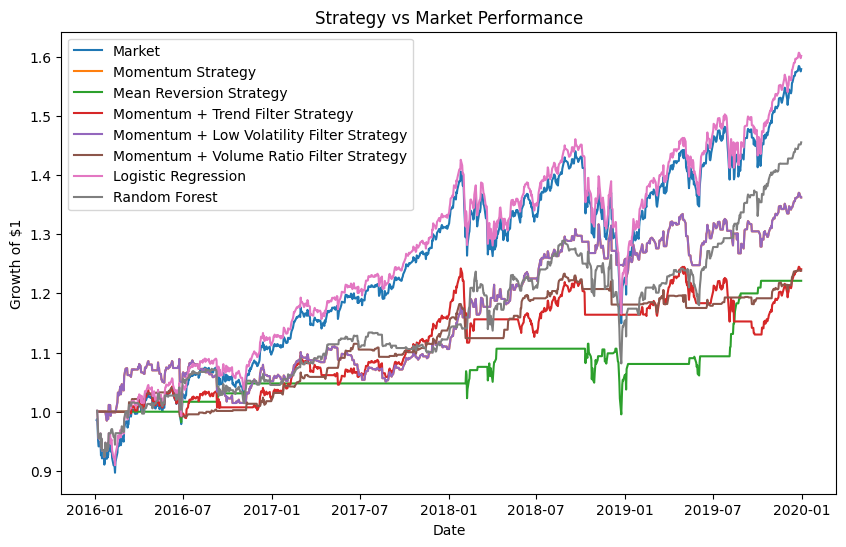


COVID
                        Strategy    Sharpe  Volatility    Max DD  \
0                         Market  0.613956    0.334469 -0.341047   
1                       Momentum  1.366030    0.178117 -0.126878   
2                 Mean Reversion -0.408914    0.282449 -0.308511   
3      Momentum + Trend Strength  0.951863    0.144070 -0.098015   
4  Momentum + Rolling Volatility  2.469428    0.115940 -0.051449   
5        Momentum + Volume Ratio  0.633751    0.093480 -0.099436   
6            Logistic Regression  0.613956    0.334469 -0.341047   
7                  Random Forest -0.316943    0.257947 -0.363787   

   Signal Accuracy  Signal Precision  Signal Recall  Signal Active %  
0              NaN               NaN            NaN              NaN  
1         0.529644          0.583333       0.627586        61.660079  
2         0.422925          0.487805       0.137931        16.205534  
3         0.557312          0.596491       0.703448        67.588933  
4         0.537549       

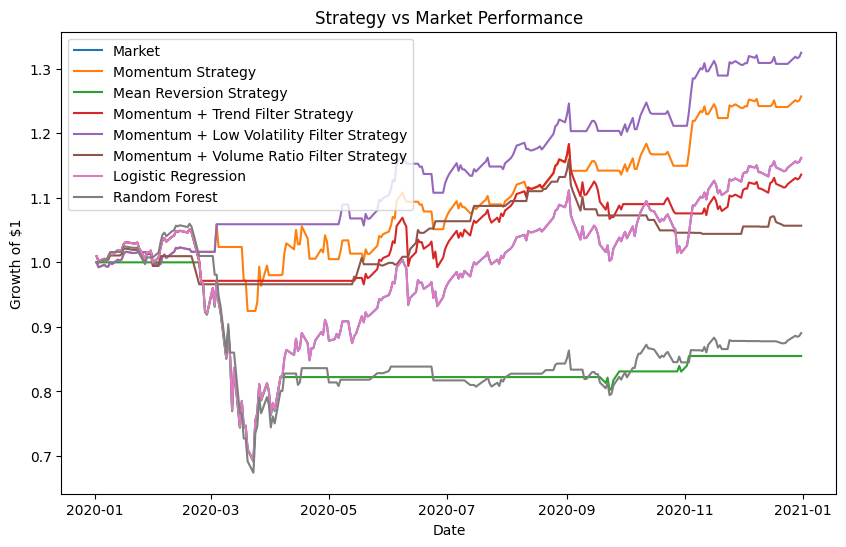


Recovery
                        Strategy    Sharpe  Volatility    Max DD  \
0                         Market  0.542937    0.176611 -0.253606   
1                       Momentum -0.390934    0.119442 -0.271016   
2                 Mean Reversion  0.630056    0.109763 -0.096401   
3      Momentum + Trend Strength  0.398203    0.109791 -0.186822   
4  Momentum + Rolling Volatility -0.477738    0.114161 -0.286599   
5        Momentum + Volume Ratio  0.112365    0.067937 -0.126337   
6            Logistic Regression  0.542937    0.176611 -0.253606   
7                  Random Forest  0.766029    0.148146 -0.148238   

   Signal Accuracy  Signal Precision  Signal Recall  Signal Active %  
0              NaN               NaN            NaN              NaN  
1         0.500664          0.521429       0.555838        55.776892  
2         0.479416          0.506173       0.208122        21.513944  
3         0.512616          0.530474       0.596447        58.831341  
4         0.501992    

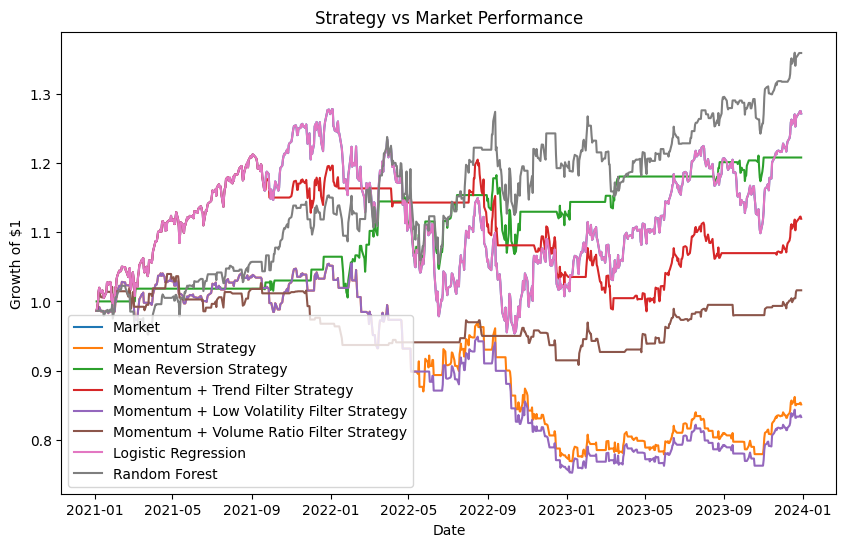


Recent
                        Strategy    Sharpe  Volatility    Max DD  \
0                         Market  1.188264    0.163550 -0.189989   
1                       Momentum  0.826368    0.101296 -0.111543   
2                 Mean Reversion  0.403370    0.113541 -0.096806   
3      Momentum + Trend Strength  0.782413    0.102820 -0.104026   
4  Momentum + Rolling Volatility  0.786273    0.090906 -0.072011   
5        Momentum + Volume Ratio  1.191796    0.062178 -0.046411   
6            Logistic Regression  1.188264    0.163550 -0.189989   
7                  Random Forest  0.782644    0.133173 -0.159871   

   Signal Accuracy  Signal Precision  Signal Recall  Signal Active %  
0              NaN               NaN            NaN              NaN  
1         0.521912          0.581169       0.617241        61.354582  
2         0.436255          0.563636       0.106897        10.956175  
3         0.507968          0.556136       0.734483        76.294821  
4         0.507968      

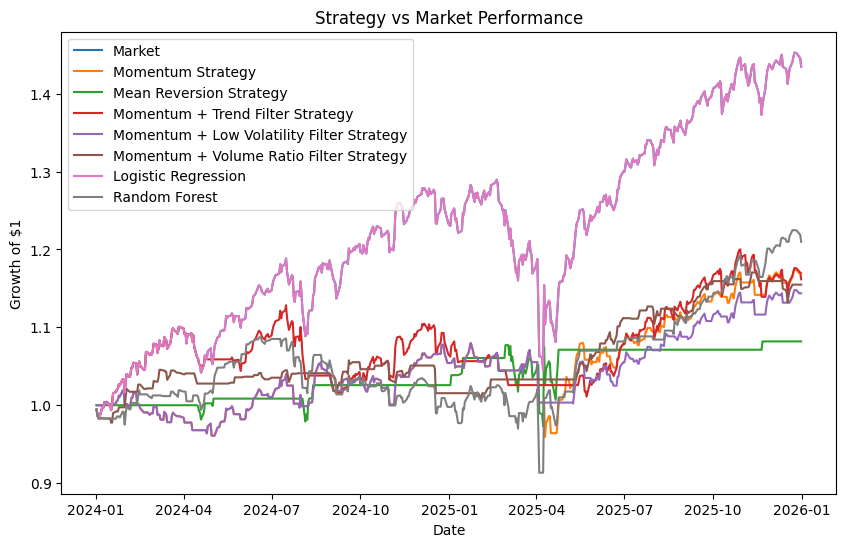

In [140]:
for name, (start, end) in periods.items():

    period = future_results.loc[start:end].copy()

    period["market_cumulative"] = (
        1 + period["returns"]
    ).cumprod()

    for _, _, ending, _, _ in strategies:

        returns = f"strategy_returns_{ending}"
        cumulative = f"cumulative_returns_{ending}"

        if returns in period.columns:
            period[cumulative] = (
                1 + period[returns]
            ).cumprod()

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    print(results_table(period, strategies))

    plot_performance(period)

## Beta Computation

In [141]:
spy_df = get_data("SPY", "2016-01-01", "2026-01-01")
spy_df = generate_features(spy_df)

market_returns = spy_df["returns"].dropna()

[*********************100%***********************]  1 of 1 completed


In [142]:
df = pd.read_csv("../outputs/experiment_results.csv")

asset_avg = (
    df.groupby("Asset")["Test Sharpe"]
      .mean()
      .sort_values(ascending=False)
)

In [143]:
columns = ['Asset', 'Beta', 'Avg Test Sharpe']
df = pd.DataFrame(columns = columns)

In [144]:
assets = ['AAPL', 'MSFT','NVDA','TTD','DOCS','IBM','BE','XOM','GLD','JNJ','SCCO','ECL','JPM','META']


In [145]:
for asset in assets:
    asset_df = get_data(asset, "2016-01-01", "2026-01-01")
    asset_df = generate_features(asset_df)

    combined = pd.concat(
        [
            asset_df["returns"],
            spy_df["returns"]
        ],
        axis=1
    ).dropna()

    beta = calculate_beta(
        combined.iloc[:, 0],
        combined.iloc[:, 1]
    )

    df.loc[len(df)] = [asset, beta, asset_avg[asset]]

df

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
/var/folders/f5/793n94tx3jj8c_rrt1drx2g40000gn/T/ipykernel_62910/4086232039.py:5: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  combined = pd.concat(
[*********************100%***********************]  1 of 1 completed
/var/folders/f5/793n94tx3jj8c_rrt1drx2g40000gn/T/ipykernel_62910/4086232039.py:5: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True`

,Asset,Beta,Avg Test Sharpe
0,AAPL,1.213043,0.882430
1,MSFT,1.178747,0.719039
2,NVDA,1.798033,1.456602
3,TTD,1.773262,-0.160005
4,DOCS,1.488148,0.324593
5,IBM,0.821961,1.043633
6,BE,1.842010,0.665593
7,XOM,0.812041,-0.038507
8,GLD,0.041616,1.433605
9,JNJ,0.462261,0.544844


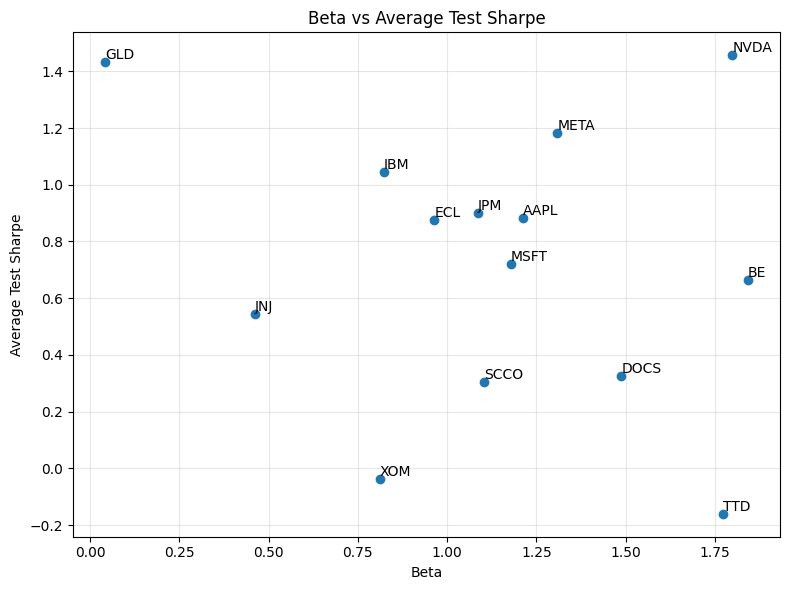

In [149]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["Beta"],
    df["Avg Test Sharpe"]
)

for _, row in df.iterrows():
    plt.text(
        row["Beta"],
        row["Avg Test Sharpe"],
        row["Asset"],
        ha="left",
        va="bottom"
    )

plt.xlabel("Beta")
plt.ylabel("Average Test Sharpe")
plt.title("Beta vs Average Test Sharpe")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()